# Lab 4a - Introduction to Perceptrons

In the first part of this lab, we will learn about gradient desecent, an optimization algorithm. We will also build a perceptron from scratch and show how we can use gradient descent to find the weights. 

Part B of the lab will apply this in a neural network for regeression to predict COVID19 cases. 

Created by: Tuan Do

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.metrics import accuracy_score
from sklearn import datasets, model_selection
import pandas as pd
import seaborn as sns # reminder: you may use any plotting tool you like!

# Gradient Descent
We will introduce gradient descent by fitting a line, also called linear regression. You wouldn't ordinarily use gradient descent with linear regression because you can just solve directly with the closed form least squares equation. 
But, for demonstration purposes we will use gradient descent on a linear regression example. In this way, using gradient descent which is iterative, we can tweak various hyperparameters to minimize a cost function. Hyperparameters include the size of the steps taken to find the minimum, called the learning rate. If the learning rate is too small, the algorithm will have to iterate many times before converging, which is slow. Conversely, if the learning rate is too high, you might end up not converging to the global minimum. When using gradient descent, you should ensure features have a similar scale to speed up convergence. Oftentimes in ML literature, you will see the learning rate set to a default parameter. Of course, you can test out various learning rates and see what happens, part of our exercise task.  

There are a variety of gradient descent algorithms, and the 'best' change often, we will use the batch gradient descent which you would likely not use in real life, but it provides an understanding of the algorithm's inner workings. We will use a common lost function (related to the MSE):  

$$J(\theta) = \frac{1}{2m}\sum_{i=1}^m (h_{\theta}(x^{(i)}) - y^{(i)})^2$$

(when you see it in this form: $h_{\theta} = \theta^Tx$).

and taking the partial derivatives of the cost function,  
$$\frac{\partial}{\partial\theta_j} = \frac{1}{m}\sum\limits_{i=1}^m (h_{\theta}(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$$

This cost function is 'nice' because their first derivatives are convex.  
HOML uses the matrix form of the cost function and its partial derivatives (shown here: https://rpubs.com/dnuttle/ml-linear-cost-func-derivative), but here we will break it down into a simpler form so you can see the steps easier. We use the classic y = mx + b function for a line, and loss is the error in the predicted value of m and b (ordinary least squares). We will initialize m and b to 0, and they will be updated iteratively as the error becomes smaller. so then our cost function now becomes  

$$E  = \frac{1}{n}\sum\limits_{i=1}^n (y_{i} - (mx_{i} + b))^2$$

Notice we changed m to n because m is now our slope. And what happened to the 1/2 in the other cost function? Well, we are showing you what you'll see out there in the real world- some are multiplied by 1/2 so when you take the partial derivatives they cancel, at any rate its just a constant so it doesn't matter for optimization. Now, we need the partial derivatives with respect to m and b:

$$D_{m} = \frac{-2}{n}\sum\limits_{i=1}^n x_{i}(y_{i} - \hat{y_{i}})$$

which becomes in our code: `D_m = (-2/n) * sum(X * (y - Y_pred))`  # Derivative wrt m.  

Likewise the partial derivative wrt b is:  
$$D_{b} =  \frac{-2}{n}\sum\limits_{i=1}^n (y_{i} - \hat{y_{i}})$$

(see https://ml-cheatsheet.readthedocs.io/en/latest/linear_regression.html for how to compute each partial derivative)
I'll leave it to you as an exercise to translate into code.

Text(0, 0.5, 'y')

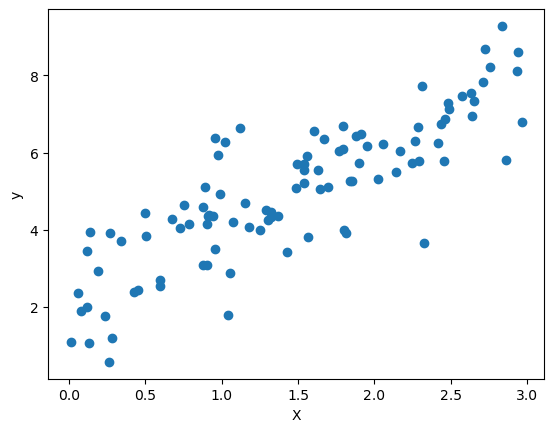

In [2]:
## Create some linear data
# Let's  generate some random linearish data so we can fit it with gradient descent
np.random.seed(10)
X = 3* np.random.rand(100,1)
y = 2 + 2*X + np.random.randn(100,1)

plt.scatter(X,y)
plt.xlabel('X')
plt.ylabel('y')

## <font color='red'>Question 1 (8 pts)

To create a gradient step algorithm, we set m and b to 0 (this starts our prediction where?)  
We also need to set a learning rate, let's try L = 0.0001 
In our loop, 

1. set Y_pred = m*X + b, the current predicted value of Y

2. get derivative wrt m, set it to D_m

3. get derivative wrt b, set it to D_b

4. update m by m - L*D_m

5. update b

6. print out m, b and in a cell below plot your best fit line on the scatter plot.

7. Describe the quality of the fit and how it changes as you change the learning rate and number of epochs. 

8. Make a plot of the loss as a function of epoch for your best model fit. 
</font>

In [4]:
m = 0
b = 0
L = 0.0001  # The learning Rate
epochs = 1000  # The number of iterations to perform gradient descent
n = float(len(X)) # Number of elements in X

Y_pred = m*X +b

# Performing Gradient Descent 
for i in range(epochs): 
    # FILL IN CODE HERE
    D_m = -2*(1/n)*np.sum(X*(y - Y_pred))
    D_b = -2*(1/n)*np.sum((y - Y_pred))
    m = m - L*D_m
    b = b - L*D_b    
    
print (m,b)

1.7071624872870872 0.9968960400081606



# Understanding Perceptrons: The Building Blocks of Neural Networks

## What is a Perceptron?

A perceptron is one of the simplest forms of artificial neural networks. Invented in 1957 by Frank Rosenblatt, it serves as a binary classifier that makes decisions by combining input signals with weights and applying an activation function.

## How Does a Perceptron Work?

A perceptron works in three main steps:

1. **Input Processing**:
   - Takes multiple input signals (x₁, x₂, ..., xₙ)
   - Each input has an associated weight (w₁, w₂, ..., wₙ)
   - There's also a bias term (b) that helps shift the decision boundary

2. **Weighted Sum**:
   - Multiplies each input by its weight: w₁x₁ + w₂x₂ + ... + wₙxₙ
   - Adds the bias: z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b

3. **Activation Function**:
   - Applies an activation function to the weighted sum
   - For binary classification, often uses a step function or sigmoid:
     - Step: output = 1 if z ≥ 0, else 0
     - Sigmoid: output = 1/(1 + e^(-z))

## Training a Perceptron

The perceptron learns through a simple algorithm:

1. Initialize weights and bias randomly
2. For each training example:
   - Make a prediction
   - Compare with actual target value
   - Update weights if prediction is wrong:
     - w_new = w_old + α(target - prediction)x
     where α is the learning rate

## Limitations

Perceptrons have some important limitations:

- Can only learn linearly separable patterns
- Cannot solve XOR problem
- Binary classification only (in its basic form)

## Applications

Despite limitations, perceptrons are useful for:

- Understanding basic neural network concepts
- Simple binary classification tasks
- Building blocks for more complex neural networks



# Understanding Gradient Descent in the Perceptron Problem

## Overview
Gradient descent is used to optimize the perceptron's weights by minimizing the error between predicted and actual outputs. In our implementation, we use gradient descent to iteratively adjust the weights and bias to find the optimal decision boundary.

## How it Works

Let's start with one perceptron with 2 input nodes. The input nodes have feature values x₁ and x₂. The perceptron has three weights: w₁,w₂, and b. We will be using a sigmoid activation function. 

1. **Forward Pass**:
   - Input values are multiplied by weights: z = w₁x₁ + w₂x₂ + b
   - Result is passed through sigmoid activation: σ(z) = 1/(1 + e^(-z))
   - This gives us our prediction ŷ

2. **Error Calculation**:
   - We use Mean Squared Error (MSE): E = ½(y - ŷ)²
   - y is the true label (0 or 1)
   - ŷ is our prediction (between 0 and 1)

3. **Backward Pass (Gradient Descent)**:
   - We calculate how much each weight contributed to the error
   - For weights: ∂E/∂w = (y - ŷ) × x × ŷ(1-ŷ)
   - For bias: ∂E/∂b = (y - ŷ) × ŷ(1-ŷ)
   - The term ŷ(1-ŷ) comes from derivative of sigmoid function

4. **Weight Update**:
   - Weights are updated using learning rate (α):
   - w_new = w_old + α × ∂E/∂w
   - b_new = b_old + α × ∂E/∂b
   - Learning rate determines step size of updates

## Visualization

In our implementation, we can see gradient descent in action through:
1. Decision boundary plot before and after training
2. Loss curve showing error reduction over time
3. Final classification regions showing learned decision boundary

## Key Parameters

- Learning rate (default = 0.01): Controls how big steps we take
- Epochs (default = 100): Number of passes through training data
- These hyperparameters affect:
  - Speed of convergence
  - Stability of training
  - Quality of final solution

Understanding gradient descent is crucial as it forms the foundation for training more complex neural networks.

## Building a perceptron

Below is some code that creates a Preceptron class with a single perceptron using the sigmoid activation function. Since the derivative of the sigmoid function is analytic, computing the gradient for gradient descent is straightfoward. 

Below is some example code for building a perceptron

```

import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, input_size):
        """
        Initialize a perceptron with given input dimensions
        Args:
            input_size: Number of input features
        """
        # Initialize weights using normal distribution for better initial convergence
        self.weights = np.random.randn(input_size)
        # Initialize bias term (equivalent to threshold in basic perceptron)
        self.bias = np.random.randn()
        
    def forward(self, x):
        """
        Forward pass computes weighted sum and applies activation
        Args:
            x: Input features array
        Returns:
            Output after sigmoid activation
        """
        # Compute weighted sum: w^T * x + b
        
        # IMPLEMENT HERE
        z = ...

        # Apply sigmoid activation: f(z) = 1/(1 + e^(-z))
        # Sigmoid maps any input to (0,1) range, useful for binary classification
        f = ...

        # return the value after activation
        return f
    
    def backward(self, x, y, output):
        """
        Compute gradients for weight update using chain rule
        Args:
            x: Input features
            y: True label
            output: Predicted output from forward pass
        Returns:
            Gradients for weights and bias
        """
        # Error term (y - ŷ)
        error = y - output
        # Gradient includes:
        # 1. Error term
        # 2. Derivative of sigmoid: f'(x) = f(x)(1-f(x))
        

## <font color='red'> Question 2 (4 pts)

1. Use the example code or implement your own perceptron with sigmoid activation function. If using the example code, I recommend manually typing it out to get a feel for the code and syntax. (2 pts)
2. Show an example of using the forward pass to predict a value of Y given X with the intial randomized weights. (1 pt)
3. What are range of possible outputs values for this perceptron? (1 pt)
</font>

In [24]:
# use the example code or implement your own perceptron with sigmoid activation function. If using the example code,fill in the forward() function to compute the forward pass. 

import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, input_size):
        """
        Initialize a perceptron with given input dimensions
        Args:
            input_size: Number of input features
        """
        self.weights = np.random.randn(input_size)
        self.bias = np.random.randn() # for one perceptron, need one bias

    def forward(self, x):
        """
        Forward pass computes a weighted sum and applies activation
        Args:
            x: Input features array
        Returns:
            Output after sigmoid activation
        """
        # Compute weighted sum: w^T * x + b

        z = self.weights @ x + self.bias
        # Apply sigmoid activation: f(z) = 1/(1+e^(-z))
        f = 1/(1 + np.exp(-z))
        return f

    def backward(self, x, y, output):
        """
        Compute gradients for weight update using chain rule
        Args:
            x: Input features
            y: True label
            output: Predicted output from forward pass
        Returns:
            Gradients for weights and bias
        """
        f = output # forward(self,x)
        D_w = 2 * (y - f)* f*(1-f) * x
        D_b = 2 * (y - f)
       
        # epochs = 1000
        # L = 0.0001 # learning rate
        # for i in range(epochs):
        #     self.weight = self.weight - D_w * L
        #     self.bias = self.bias - D_b * L
        
        # # self.z_new = self.weights * x + self.bias
        # # self.f_new = 1/(1+np.exp(-z_new))
        return D_w, D_b

# Answers

(1) The return value f of my forward function is the prediction.
(2) Code below.
(3) What are range of possible outputs values for this perceptron? a real number between 0 and 1.


In [25]:
np.random.seed(10)
X = 3* np.random.rand(3,1)
# y = 2 + 2*X + np.random.randn(3,1)
perc = Perceptron(X.shape[0])
print(perc.forward(X))

[0.14335665]


## Training a perceptron

To train a perceptron, we will use backpropagation. For training, one needs to decide on the hyperparameters such as the learning rate and the number of epochs to train for. 

Below is some example code for implementing the training

```


First, let's create an artificial dataset for training and evaluation

In [26]:

# generate features for binary classification
np.random.seed(123) # set seed for reproducibility
X = np.random.randn(200, 2)  # 200 samples total
y = (X[:, 0] + X[:, 1] > 0).astype(float)  # y is the OR gate.

# Split into training and validation sets (80-20 split)
split_idx = int(0.8 * len(X))
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

len(X_train)
X_train[0]

array([-1.0856306 ,  0.99734545])

Then we'll need to set some hyperparameters

In [27]:
# Hyperparameters
learning_rate = 0.1
epochs = 100


Now, we can create and train the perceptron. You can use the code below or create your own code to train and plot the results

```
# Create and train the perceptron
perceptron = Perceptron(input_size=2)

def calculate_loss(model, X, y):
    total_loss = 0
    for i in range(len(X)):
        output = model.forward(X[i])
        total_loss += 0.5 * (y[i] - output)**2
    return total_loss / len(X)

# Training with validation
training_losses = []
validation_losses = []

for epoch in range(epochs):
    epoch_loss = 0
    
    # Training pass
    for i in range(len(X_train)):
        output = perceptron.forward(X_train[i])
        loss = 0.5 * (y_train[i] - output)**2
        epoch_loss += loss
        
        d_weights, d_bias = perceptron.backward(X_train[i], y_train[i], output)
        perceptron.weights += learning_rate* d_weights
        perceptron.bias += learning_rate * d_bias
    
    # Calculate average losses
    train_loss = epoch_loss / len(X_train)
    val_loss = calculate_loss(perceptron, X_val, y_val)
    
    training_losses.append(train_loss)
    validation_losses.append(val_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(training_losses, label='Training Loss')
plt.plot(validation_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Time')
plt.legend()
plt.show()

# Plot decision boundaries with both training and validation data
plt.figure(figsize=(10, 8))
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z = np.zeros(xx.shape)
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        Z[i, j] = perceptron.forward(np.array([xx[i, j], yy[i, j]]))

plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap=plt.cm.RdYlBu, alpha=0.6)

# Plot training data
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
           cmap=plt.cm.RdYlBu, marker='o', label='Training Data')

# Plot validation data
plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val,
           cmap=plt.cm.RdYlBu, marker='^', label='Validation Data')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary with Training and Validation Data')
plt.legend()
plt.colorbar()
plt.show()
```



Epoch 0, Train Loss: 0.0544, Val Loss: 0.0514
Epoch 10, Train Loss: 0.0238, Val Loss: 0.0269
Epoch 20, Train Loss: 0.0199, Val Loss: 0.0220
Epoch 30, Train Loss: 0.0177, Val Loss: 0.0194
Epoch 40, Train Loss: 0.0163, Val Loss: 0.0177
Epoch 50, Train Loss: 0.0153, Val Loss: 0.0165
Epoch 60, Train Loss: 0.0144, Val Loss: 0.0156
Epoch 70, Train Loss: 0.0138, Val Loss: 0.0148
Epoch 80, Train Loss: 0.0132, Val Loss: 0.0142
Epoch 90, Train Loss: 0.0127, Val Loss: 0.0137
runtime: 0.157026



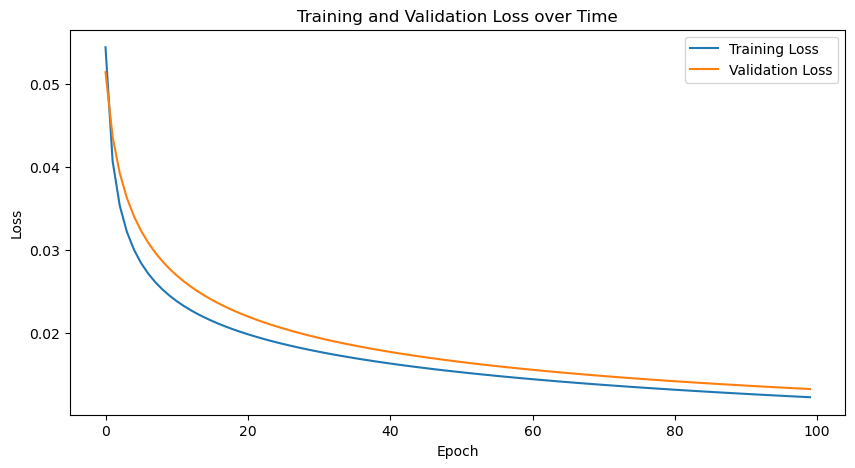

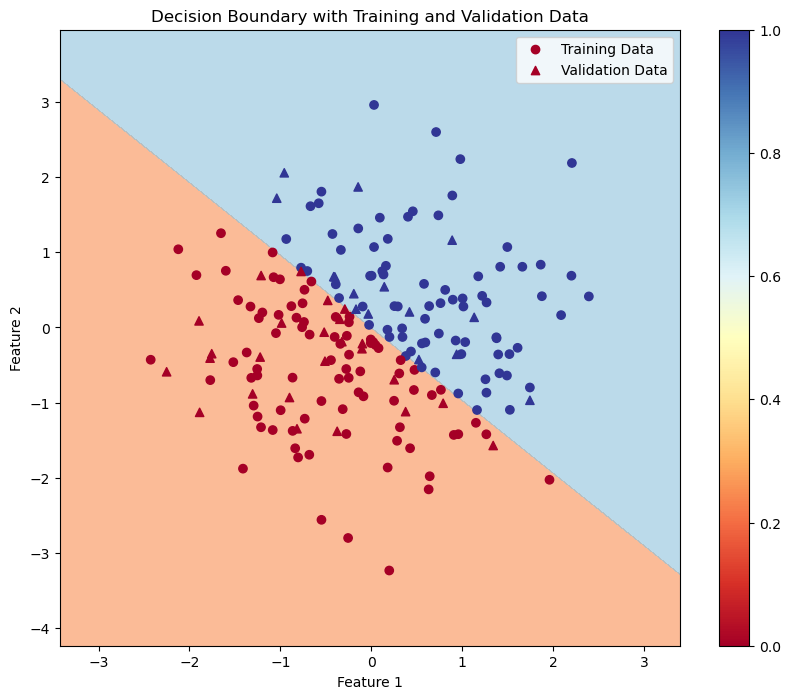

In [31]:
# this code updates the weight based on one sample; it is an efficient algorithm
# more precise one is updating the weight based on the loss summed over all samples. 
# Create and train the perceptron
import time

t0 = time.time()

perceptron = Perceptron(input_size=2)

def calculate_loss(model, X, y):
    total_loss = 0
    for i in range(len(X)):
        output = model.forward(X[i])
        total_loss += 0.5 * (y[i] - output)**2
    return total_loss / len(X)

# Training with validation
training_losses = []
validation_losses = []

for epoch in range(epochs):
    epoch_loss = 0
    
    # Training pass
    for i in range(len(X_train)):
        output = perceptron.forward(X_train[i])
        loss = 0.5 * (y_train[i] - output)**2 # I'm not sure why they compute the loss based on 'partial' gradient(\partial_w C_i ) instead the total gradient, \sum_{i=1}^{num sample} \partial_w C_i
        epoch_loss += loss
        
        d_weights, d_bias = perceptron.backward(X_train[i], y_train[i], output)
        perceptron.weights += learning_rate* d_weights
        perceptron.bias += learning_rate * d_bias
    
    # Calculate average losses
    train_loss = epoch_loss / len(X_train)
    train_loss2 = calculate_loss(perceptron, X_val, y_val)
    val_loss = calculate_loss(perceptron, X_val, y_val)
    
    training_losses.append(train_loss)
    validation_losses.append(val_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

t1 = time.time()

total = t1-t0

print(f'runtime: {total :4f}\n')
# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(training_losses, label='Training Loss')
plt.plot(validation_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Time')
plt.legend()
plt.show()

# Plot decision boundaries with both training and validation data
plt.figure(figsize=(10, 8))
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z = np.zeros(xx.shape)
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        Z[i, j] = perceptron.forward(np.array([xx[i, j], yy[i, j]]))

plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap=plt.cm.RdYlBu, alpha=0.6)

# Plot training data
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
           cmap=plt.cm.RdYlBu, marker='o', label='Training Data')

# Plot validation data
plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val,
           cmap=plt.cm.RdYlBu, marker='^', label='Validation Data')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary with Training and Validation Data')
plt.legend()
plt.colorbar()
plt.show()

# New code
The above example code updates the weights based on the loss (error) of each sample.  The code below updates weights/biases based on the cost function which is the sum of loss over all samples.
The total loss for training and validation sets decrease over time, similarly for the above code.  The runtime is slower than above code.

Epoch 0, Train Loss: 0.2896, Val Loss: 0.2522
Epoch 10, Train Loss: 0.0239, Val Loss: 0.0290
Epoch 20, Train Loss: 0.0194, Val Loss: 0.0229
Epoch 30, Train Loss: 0.0172, Val Loss: 0.0199
Epoch 40, Train Loss: 0.0158, Val Loss: 0.0181
Epoch 50, Train Loss: 0.0148, Val Loss: 0.0168
Epoch 60, Train Loss: 0.0140, Val Loss: 0.0158
Epoch 70, Train Loss: 0.0133, Val Loss: 0.0150
Epoch 80, Train Loss: 0.0127, Val Loss: 0.0143
Epoch 90, Train Loss: 0.0122, Val Loss: 0.0138
runtime: 0.190283



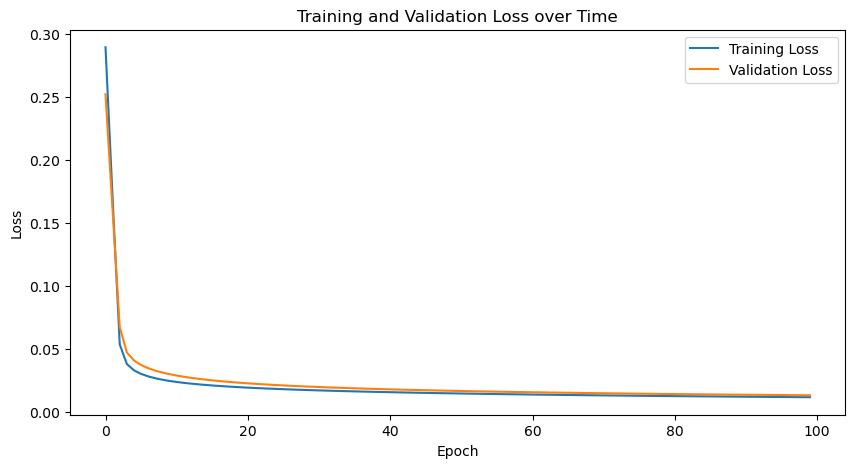

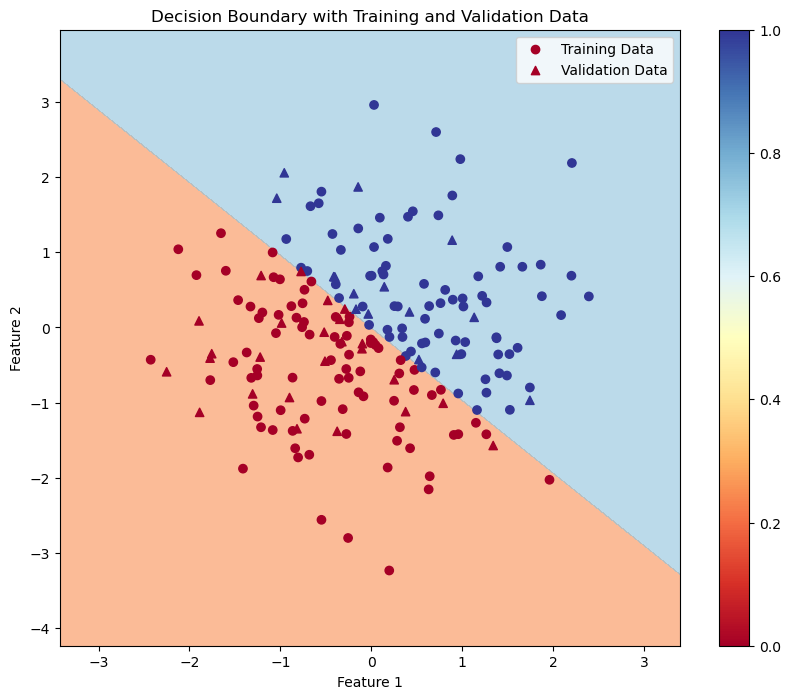

In [37]:
# My code using the summed loss, instead of the loss for each sample.
import time

t0 = time.time()

perc = Perceptron(input_size=2)
def calculate_loss(model, X, y):
    total_loss = 0
    for i in range(len(X)):
        output = model.forward(X[i])
        total_loss += 0.5 * (y[i] - output)**2
    return total_loss / len(X)

# Training with validation
training_losses = []
validation_losses = []

# enter the loop of epochs to compute epoch loss and update weight and biases
for epoch in range(epochs):
    # compute epoch losses
    epoch_loss = calculate_loss(perc, X_train, y_train)
    val_epoch_loss = calculate_loss(perc, X_val, y_val)
    training_losses.append(epoch_loss)
    validation_losses.append(val_epoch_loss)
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}')
        
    # update weight and biases
    for i in range(len(X_train)):
        f = perc.forward(X_train[i])
        D_w, D_b = perc.backward(X_train[i],y_train[i],f)
        perc.weights += learning_rate * D_w # * 1/len(X_train)
        perc.bias += learning_rate * D_b # * 1/len(X_train)


t1 = time.time()

total = t1-t0
print(f'runtime: {total :4f}\n')
# Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(training_losses, label='Training Loss')
plt.plot(validation_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Time')
plt.legend()
plt.show()

# Plot decision boundaries with both training and validation data
plt.figure(figsize=(10, 8))
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z = np.zeros(xx.shape)
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        Z[i, j] = perceptron.forward(np.array([xx[i, j], yy[i, j]]))

plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap=plt.cm.RdYlBu, alpha=0.6)

# Plot training data
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
           cmap=plt.cm.RdYlBu, marker='o', label='Training Data')

# Plot validation data
plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val,
           cmap=plt.cm.RdYlBu, marker='^', label='Validation Data')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary with Training and Validation Data')
plt.legend()
plt.colorbar()
plt.show()

## <span style="color:red"><font color='red'>Question 3 (6 pts)

Use your perceptron and example training above to help answer the following questions. 

How many free parameters are in the model? (1 pt)

How is gradient descent used? (2 pt)

Describe what happens when the learning rate and the number of epochs are changed. How do the learning curves behave? (3 pts)
</font></span>


# Answers

How many free parameters are in the model? (1 pt)
> two: number of epochs, learning rate (step size), 

How is gradient descent used? (2 pt)
> For each sample, the gradient of loss is computed and added to the weight and bias. The updated weight and bias from previous sample is used in computing the loss of the next sample, whose gradient updates the new weight and bias.  Repeats for all samples.  This happen within one epoch.  We repeat this process for all epochs.

Describe what happens when the learning rate and the number of epochs are changed. How do the learning curves behave? (3 pts)
> Naively, too small learning rate makes the convergence slower and too large one might not gaurantee the convergence as it bounces off too widely.  If the loss was already converged, increasing the number of epochs wouldn't necessarily affect the performance.  However, if the loss wasn't converged, increasing the number of epochs can make it possible to converge.


# Neural Networks

Perceptrons have limited capabilities, but they become very powerful if we connect many of them together. When we connect multiple perceptrons, we can create a neural network. In a fully connected neural network, every node in one layer of the neural network is connected to the next layer. In this example, we'll build a three layer neural network, one input layer with 1 node, one hidden layer with 8 nodes, and an output layer with one node. We'll use this neural network in a simple regression example to learn a polynomial function. 

## Key Components

1. **Multiple Layers**
   - The hidden layer with 8 nodes allows the network to learn more complex patterns
   - Each node in hidden layer acts like a mini-perceptron
   - Network combines these nodes' outputs to make final prediction

2. **ReLU Activation**
   - Uses Rectified Linear Unit (ReLU) in hidden layer: f(x) = max(0,x)
   - Helps network learn non-linear patterns
   - This activation is commonly used in modern neural networks. It is fast to compute and reduces vanishing gradient problem. 

3. **Forward Propagation**
   - Input → Hidden layer weights (W1) and bias (b1)
   - ReLU activation on hidden layer
   - Hidden → Output weights (W2) and bias (b2)

4. **Backpropagation**
   - Calculates gradients for all weights and biases
   - Uses chain rule to propagate error backwards
   - Updates all parameters to minimize loss

## Advantages Over Perceptron

1. **Non-linear Learning**
   - Can approximate any continuous function
   - Not limited to linear decision boundaries
   - Better suited for complex real-world problems

2. **Regression Capability** 
   - Can output continuous values
   - Not limited to binary classification
   - More versatile for different types of problems

3. **Feature Learning**
   - Hidden layer learns useful feature representations
   - Combines features in non-linear ways
   - More powerful than raw input features

## Trade-offs
- More complex to train than perceptron
- Requires more computational resources
- More hyperparameters to tune
- Risk of overfitting with too many nodes


We've included the code for a basic neural network below. You can use this code for the next questions, but make sure you understand what it does!

In [2]:

import numpy as np

class NeuralNetwork:
    def __init__(self, input_size):
        # Initialize weights and biases
        self.input_size = input_size
        self.hidden_size = 8  # 8 nodes in hidden layer
        self.output_size = 1  # 1 node for regression output
        
        # Initialize weights with random values
        self.W1 = np.random.randn(self.input_size, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, self.output_size) * 0.01
        self.b2 = np.zeros((1, self.output_size))
        
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return np.where(x > 0, 1, 0)
    
    def forward(self, X):
        # Forward propagation
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1) # a1: neurons in the hidden layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        return self.z2 # no activation from the hidden layer
    
    def backward(self, X, y, y_pred, learning_rate):
        m = X.shape[0]
        
        # Backpropagation
        dz2 = (y_pred - y)
        dW2 = (1/m) * np.dot(self.a1.T, dz2) # dz2 is N*1, a1 is N*8 columns for N samples. Transpose it to make 8*N and then this becomes the sum over sample.
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True) # This is sum over samples.
        
        da1 = np.dot(dz2, self.W2.T) # dz2 is N*1, W2.T is N*1*8, da1 is N*8 (8 columns)
        dz1 = da1 * self.relu_derivative(self.z1) # dz1 is N*8
        dW1 = (1/m) * np.dot(X.T, dz1) # X.T is 1*N so this computes sum X times derivatives over samples
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True) 
        
        # Update parameters
        self.W2 -= learning_rate * dW2 # dW2 is the gradient (summed over all samples)
        self.b2 -= learning_rate * db2 # db2 is also summed over all samples
        self.W1 -= learning_rate * dW1 # dW1 is also summed over all samples
        self.b1 -= learning_rate * db1 # db1 is also summed over all samples.

In [3]:

def plot_neural_network(layer_sizes, weights=None, biases=None):
    """
    Plot the neural network architecture showing nodes and connections with labels
    Args:
        layer_sizes: List of number of nodes in each layer
        weights: List of weight matrices between layers
        biases: List of bias vectors for each layer
    """
    fig = plt.figure(figsize=(12, 8))
    vertical_distance_between_layers = 6
    horizontal_distance_between_neurons = 2
    neuron_radius = 0.5
    
    # Compute positions for neurons in each layer
    layer_positions = []
    for n in layer_sizes:
        layer_y = np.linspace(-(n-1)*horizontal_distance_between_neurons/2, 
                             (n-1)*horizontal_distance_between_neurons/2, n)
        layer_positions.append(layer_y)

    # Plot neurons and connections
    for i, layer_y in enumerate(layer_positions):
        layer_x = i * vertical_distance_between_layers
        
        # Draw nodes
        for j, y in enumerate(layer_y):
            circle = plt.Circle((layer_x, y), radius=neuron_radius, fill=False)
            plt.gca().add_patch(circle)
            
            # Add bias value if provided for non-input layers
            if biases is not None and i > 0:
                plt.text(layer_x-0.7, y+0.7, f'b{i}{j}: {biases[i-1][j]:.2f}', fontsize=8)

    # Plot connections with weight labels
    if weights is not None:
        for i, (current_layer_y, next_layer_y) in enumerate(zip(layer_positions[:-1], layer_positions[1:])):
            current_layer_x = i * vertical_distance_between_layers
            next_layer_x = (i + 1) * vertical_distance_between_layers
            
            for j, start_y in enumerate(current_layer_y):
                for k, end_y in enumerate(next_layer_y):
                    weight = weights[i][j][k]
                    color = 'red' if weight < 0 else 'blue'
                    #alpha = min(abs(weight), 1.0)
                    alpha = 1
                    plt.plot([current_layer_x, next_layer_x], [start_y, end_y], 
                            color=color, alpha=alpha)
                    # Add weight label at midpoint
                    mid_x = (current_layer_x + next_layer_x) / 2
                    mid_y = (start_y + end_y) / 2
                    plt.text(mid_x, mid_y, f'w{i}{j}{k}: {weight:.2f}', 
                            fontsize=8, ha='center', va='center')

    # Add layer labels
    x_positions = np.arange(len(layer_sizes)) * vertical_distance_between_layers
    plt.xticks(x_positions, [f'Layer {i}\n({size} nodes)' 
                            for i, size in enumerate(layer_sizes)])
    
    plt.ylim(-4, 4)
    plt.title('Neural Network Architecture')
    plt.axis('equal')
    plt.show()

In [4]:
# Generate synthetic data
np.random.seed(0)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = X**2+1
#y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])
y = y.reshape(-1, 1)

# Initialize neural network
model = NeuralNetwork(input_size=1)


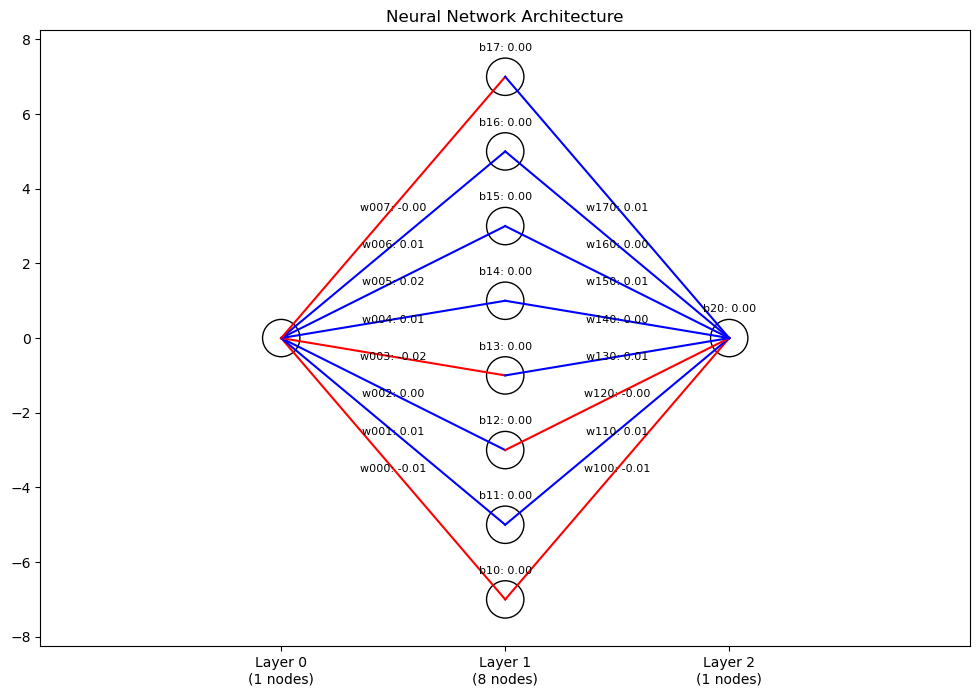

In [5]:
weights = [model.W1, model.W2]  # Do not transpose weights
biases = [model.b1.flatten(), model.b2.flatten()]  # Flatten to convert to 1D arrays
layer_sizes = [1, 8, 1]  # Input layer, hidden layer, output layer

# Visualize network architecture
plot_neural_network(layer_sizes, weights, biases)


Epoch 0, Loss: 127.1119
Epoch 100, Loss: 4.0602
Epoch 200, Loss: 2.0151
Epoch 300, Loss: 1.3507
Epoch 400, Loss: 1.1344
Epoch 500, Loss: 1.0005
Epoch 600, Loss: 0.7408
Epoch 700, Loss: 0.5323
Epoch 800, Loss: 0.4085
Epoch 900, Loss: 0.2734


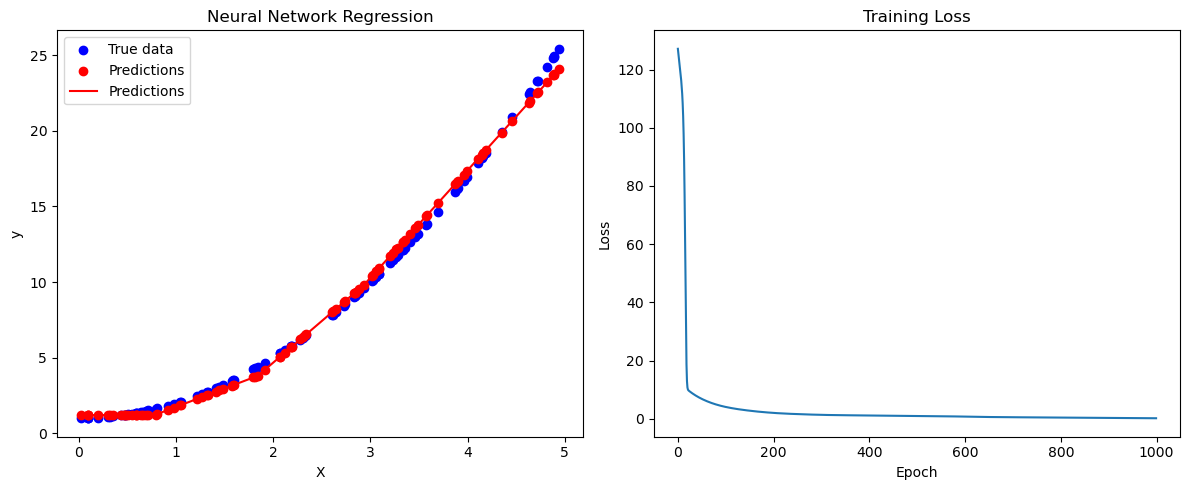

In [6]:

# Training parameters
epochs = 1000
learning_rate = 0.01
losses = []

# Train the model
for epoch in range(epochs):
    # Forward pass
    y_pred = model.forward(X)
    
    # Calculate loss
    loss = np.mean((y_pred - y) ** 2)
    losses.append(loss)
    
    # Backward pass
    model.backward(X, y, y_pred, learning_rate) # different weights for each sample...
    
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss:.4f}')

# Plot results
plt.figure(figsize=(12, 5))

# Plot training results
plt.subplot(1, 2, 1)
plt.scatter(X, y, color='blue', label='True data')
plt.scatter(X, model.forward(X), color='red', label='Predictions')
plt.plot(X, model.forward(X), color='red', label='Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Neural Network Regression')
plt.legend()

# Plot loss curve
plt.subplot(1, 2, 2)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

plt.tight_layout()
plt.show()

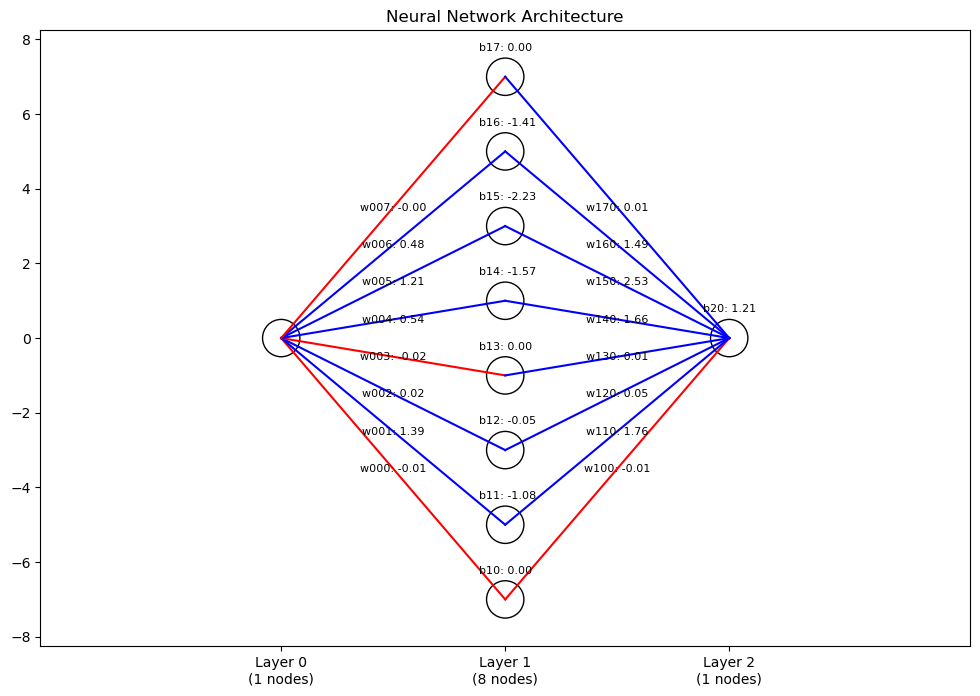

In [7]:
weights = [model.W1, model.W2]  # Do not transpose weights
biases = [model.b1.flatten(), model.b2.flatten()]  # Flatten to convert to 1D arrays
layer_sizes = [1, 8, 1]  # Input layer, hidden layer, output layer

# Visualize network architecture
plot_neural_network(layer_sizes, weights, biases)


## <span style="color:red"> <font color='red'> Question 4 (11 pts) 

Using the neural network from above, answer the following:

How many free parameters are there? How did you determine this? (1 pt)

How is gradient descent used? (2 pts)

Describe the quality of the fit to the example data with the default neural network. (1 pt)

Hypothesize why it might take so many more model parameters to fit a second order polynomial? (1 pt)

How does the changing the architecture such as the number of nodes in the hidden model affect the quality of the fit? (2 pts)

Increase the order of the polynomial that generates the data and explore how the relationship between the number of nodes and the quality of the fit for different polynomial orders. What would you conclude about the use of neural networks for this task? (4 pts)
</font>
</span>


# Answers

How many free parameters are there? How did you determine this? (1 pt)
> free parameters are weights and biases from input to hidden layer (1x8 + 8 = 16) and from hidden layer to the output layer (8x1+1 = 9).  In total, there are 25 free parameters.  I'm not sure if the values of each neuron in the hidden layer and output are also considered free parameters.  There are z1 (100x8), a1(100x8), z2 (100), in total 1700 more parameters.

How is gradient descent used? (2 pts)
> We took the derivative of the mean square error w.r.t. each free parameters using the chain rule involving the intermediate variables (values of each neuron in the hidden layer (a1), ReLU (nonlinearisation) output (z1) and output (z2)).

Describe the quality of the fit to the example data with the default neural network. (1 pt)
> Within the 100 epochs, the training loss drops dramatically and quickly converges to about 0.2 which is less than the lowest y-value among the training set (pretty accurate prediction).  

Hypothesize why it might take so many more model parameters to fit a second order polynomial? (1 pt)
> We already fit a second-order polynomial.  What do you mean by 'more'?  Higher order polynomials has more turning points.  The activation functions are monotonically increasing hence one needs more than one of them to fit two or more turning points.

How does the changing the architecture such as the number of nodes in the hidden model affect the quality of the fit? (2 pts)
> I would expect the better fit with the more neurons or more layers.

Increase the order of the polynomial that generates the data and explore how the relationship between the number of nodes and the quality of the fit for different polynomial orders. What would you conclude about the use of neural networks for this task? (4 pts)
> For y = x^3 - 5x^2 +1, a single layer, 8 neurons predicted linearly while 1000 or more neurons (even 160000 neurons) predicted a piecewise linear curve.  So the quality of fit increases with the # of neuron only to a certain extent.
> Introducing one more layer improved the fit albeit not perfect.  The last plot is with 2 layers of 400 neurons, which fits the curve better than the single layer one with the same total number of neuron.  But this also saturates with number of neurons, e.g. 500 or more neurons per layer indeed worsens the quality of fit.

Epoch 0, Loss: 0.1839
Epoch 100, Loss: 0.1839
Epoch 200, Loss: 0.1839
Epoch 300, Loss: 0.1839
Epoch 400, Loss: 0.1839
Epoch 500, Loss: 0.1839
Epoch 600, Loss: 0.1839
Epoch 700, Loss: 0.1839
Epoch 800, Loss: 0.1839
Epoch 900, Loss: 0.1839


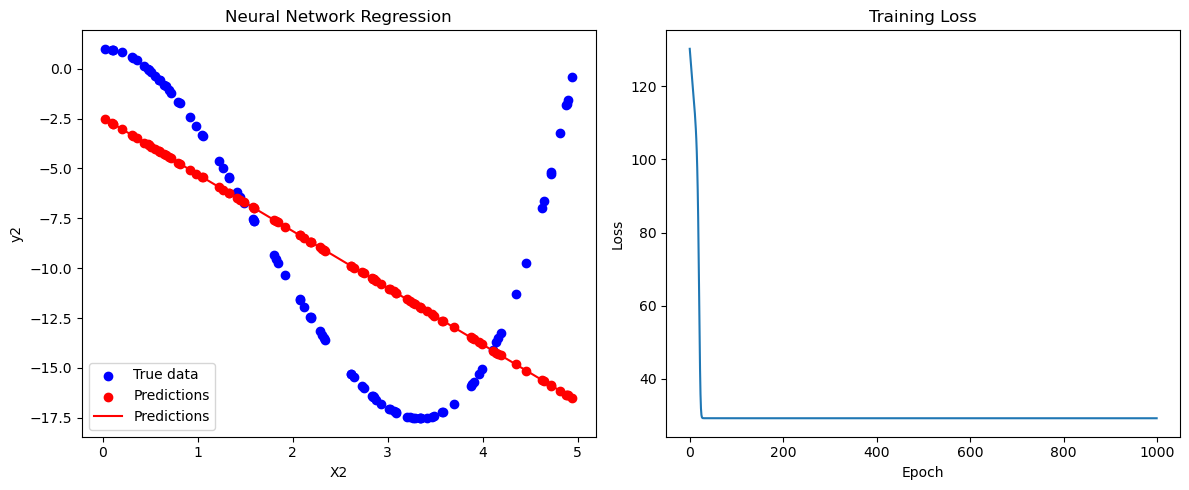

In [66]:
# As one can see below, the 8 neurons are not enough to parameterise the third order polynomial.

np.random.seed(0)
X2 = np.sort(5 * np.random.rand(100, 1), axis=0)
y2 = X2**3 - 5* X2**2 +1
#y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])
y2 = y2.reshape(-1, 1)

# Initialize neural network
model2 = NeuralNetwork(input_size=1)
losses2 = []
# training
for epoch in range(epochs):
    y_pred = model2.forward(X2)
    losses2.append(np.mean((y2-y_pred)**2))
    model2.backward(X2, y2, y_pred, learning_rate)
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss:.4f}')
    
# Plot results
plt.figure(figsize=(12, 5))

# Plot training results
plt.subplot(1, 2, 1)
plt.scatter(X2, y2, color='blue', label='True data')
plt.scatter(X2, model2.forward(X2), color='red', label='Predictions')
plt.plot(X2, model2.forward(X2), color='red', label='Predictions')
plt.xlabel('X2')
plt.ylabel('y2')
plt.title('Neural Network Regression')
plt.legend()

# Plot loss curve
plt.subplot(1, 2, 2)
plt.plot(losses2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

plt.tight_layout()
plt.show()

# Build a new neural network with more neurons

In [76]:
# With 5000 neurons in one layer

class NeuralNetwork2:
    def __init__(self, input_size):
        # Initialize weights and biases
        self.input_size = input_size
        self.hidden_size = 5000  # 8 nodes in hidden layer
        self.output_size = 1  # 1 node for regression output
        
        # Initialize weights with random values
        self.W1 = np.random.randn(self.input_size, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, self.output_size) * 0.01
        self.b2 = np.zeros((1, self.output_size))
        
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return np.where(x > 0, 1, 0)
    
    def forward(self, X):
        # Forward propagation
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1) # a1: neurons in the hidden layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        return self.z2 # no activation from the hidden layer
    
    def backward(self, X, y, y_pred, learning_rate):
        m = X.shape[0]
        
        # Backpropagation
        dz2 = (y_pred - y)
        dW2 = (1/m) * np.dot(self.a1.T, dz2) # dz2 is N*1, a1 is N*8 columns for N samples. Transpose it to make 8*N and then this becomes the sum over sample.
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True) # This is sum over samples.
        
        da1 = np.dot(dz2, self.W2.T) # dz2 is N*1, W2.T is N*1*8, da1 is N*8 (8 columns)
        dz1 = da1 * self.relu_derivative(self.z1) # dz1 is N*8
        dW1 = (1/m) * np.dot(X.T, dz1) # X.T is 1*N so this computes sum X times derivatives over samples
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True) 
        
        # Update parameters
        self.W2 -= learning_rate * dW2 # dW2 is the gradient (summed over all samples)
        self.b2 -= learning_rate * db2 # db2 is also summed over all samples
        self.W1 -= learning_rate * dW1 # dW1 is also summed over all samples
        self.b1 -= learning_rate * db1 # db1 is also summed over all samples.

Epoch 0, Loss: 0.1839
Epoch 100, Loss: 0.1839
Epoch 200, Loss: 0.1839
Epoch 300, Loss: 0.1839
Epoch 400, Loss: 0.1839
Epoch 500, Loss: 0.1839
Epoch 600, Loss: 0.1839
Epoch 700, Loss: 0.1839
Epoch 800, Loss: 0.1839
Epoch 900, Loss: 0.1839


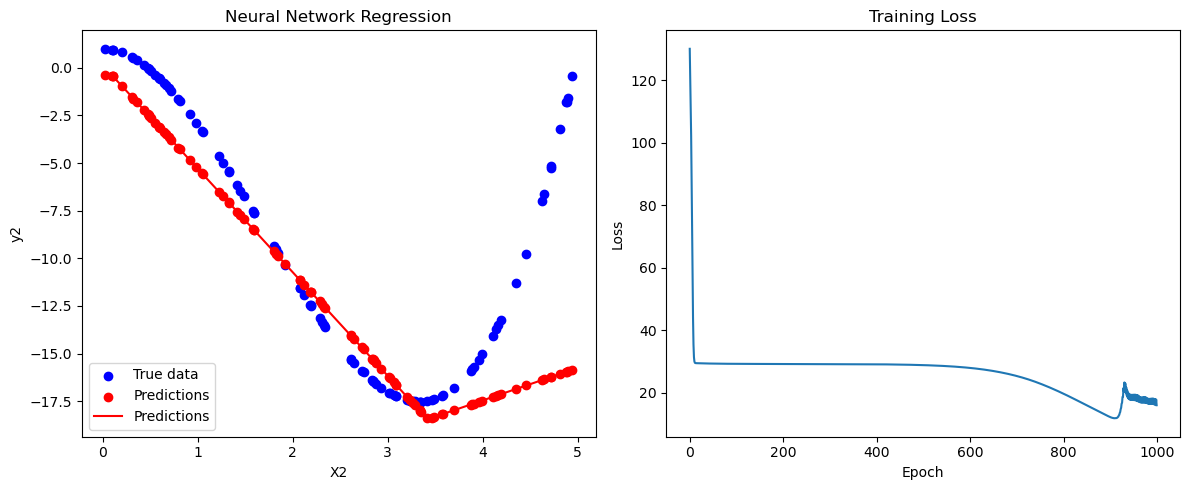

In [75]:
np.random.seed(0)
X2 = np.sort(5 * np.random.rand(100, 1), axis=0)
y2 = X2**3 - 5* X2**2 +1
#y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])
y2 = y2.reshape(-1, 1)

# Initialize neural network
model2 = NeuralNetwork2(input_size=1)
losses2 = []
# training
for epoch in range(epochs):
    y_pred = model2.forward(X2)
    losses2.append(np.mean((y2-y_pred)**2))
    model2.backward(X2, y2, y_pred, learning_rate)
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss:.4f}')
    
# Plot results
plt.figure(figsize=(12, 5))

# Plot training results
plt.subplot(1, 2, 1)
plt.scatter(X2, y2, color='blue', label='True data')
plt.scatter(X2, model2.forward(X2), color='red', label='Predictions')
plt.plot(X2, model2.forward(X2), color='red', label='Predictions')
plt.xlabel('X2')
plt.ylabel('y2')
plt.title('Neural Network Regression')
plt.legend()

# Plot loss curve
plt.subplot(1, 2, 2)
plt.plot(losses2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

plt.tight_layout()
plt.show()

Epoch 0, Loss: 0.1839
Epoch 100, Loss: 0.1839
Epoch 200, Loss: 0.1839
Epoch 300, Loss: 0.1839
Epoch 400, Loss: 0.1839
Epoch 500, Loss: 0.1839
Epoch 600, Loss: 0.1839
Epoch 700, Loss: 0.1839
Epoch 800, Loss: 0.1839
Epoch 900, Loss: 0.1839


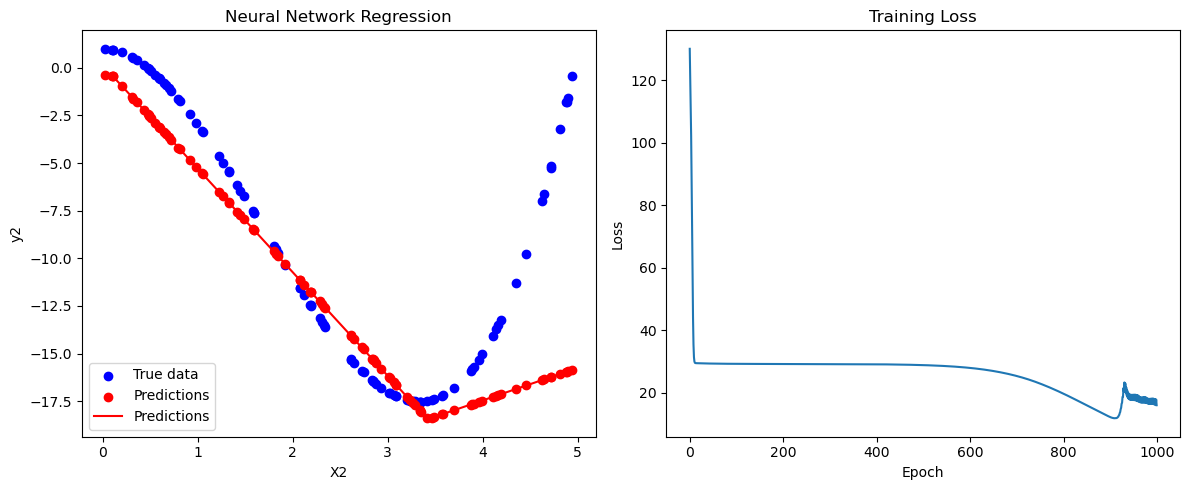

In [45]:
# 160000 neurons
class NeuralNetwork2:
    def __init__(self, input_size):
        # Initialize weights and biases
        self.input_size = input_size
        self.hidden_size = 5000  # 8 nodes in hidden layer
        self.output_size = 1  # 1 node for regression output
        
        # Initialize weights with random values
        self.W1 = np.random.randn(self.input_size, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, self.output_size) * 0.01
        self.b2 = np.zeros((1, self.output_size))
        
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return np.where(x > 0, 1, 0)
    
    def forward(self, X):
        # Forward propagation
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1) # a1: neurons in the hidden layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        return self.z2 # no activation from the hidden layer
    
    def backward(self, X, y, y_pred, learning_rate):
        m = X.shape[0]
        
        # Backpropagation
        dz2 = (y_pred - y)
        dW2 = (1/m) * np.dot(self.a1.T, dz2) # dz2 is N*1, a1 is N*8 columns for N samples. Transpose it to make 8*N and then this becomes the sum over sample.
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True) # This is sum over samples.
        
        da1 = np.dot(dz2, self.W2.T) # dz2 is N*1, W2.T is N*1*8, da1 is N*8 (8 columns)
        dz1 = da1 * self.relu_derivative(self.z1) # dz1 is N*8
        dW1 = (1/m) * np.dot(X.T, dz1) # X.T is 1*N so this computes sum X times derivatives over samples
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True) 
        
        # Update parameters
        self.W2 -= learning_rate * dW2 # dW2 is the gradient (summed over all samples)
        self.b2 -= learning_rate * db2 # db2 is also summed over all samples
        self.W1 -= learning_rate * dW1 # dW1 is also summed over all samples
        self.b1 -= learning_rate * db1 # db1 is also summed over all samples.
        
np.random.seed(0)
X2 = np.sort(5 * np.random.rand(100, 1), axis=0)
y2 = X2**3 - 5* X2**2 +1
#y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])
y2 = y2.reshape(-1, 1)

# Initialize neural network
model2 = NeuralNetwork2(input_size=1)
losses2 = []
# training
for epoch in range(epochs):
    y_pred = model2.forward(X2)
    losses2.append(np.mean((y2-y_pred)**2))
    model2.backward(X2, y2, y_pred, learning_rate)
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss:.4f}')
    
# Plot results
plt.figure(figsize=(12, 5))

# Plot training results
plt.subplot(1, 2, 1)
plt.scatter(X2, y2, color='blue', label='True data')
plt.scatter(X2, model2.forward(X2), color='red', label='Predictions')
plt.plot(X2, model2.forward(X2), color='red', label='Predictions')
plt.xlabel('X2')
plt.ylabel('y2')
plt.title('Neural Network Regression')
plt.legend()

# Plot loss curve
plt.subplot(1, 2, 2)
plt.plot(losses2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

plt.tight_layout()
plt.show()

In [43]:
# With two layers, 100 neurons each.
class NeuralNetwork3:
    def __init__(self, input_size):
        # Initialize weights and biases
        self.input_size = input_size
        self.hidden_size = 400  # 8 nodes in hidden layer
        self.output_size = 1  # 1 node for regression output
        
        # Initialize weights with random values
        self.W1 = np.random.randn(self.input_size, self.hidden_size) * 0.01 #1x10
        self.b1 = np.zeros((1, self.hidden_size)) # 1x10
        self.W2 = np.random.randn(self.hidden_size, self.hidden_size)  * 0.01 # 10x10
        self.b2 = np.random.randn(1, self.hidden_size) # 1x10
        self.W3 = np.random.randn(self.hidden_size, self.output_size) * 0.01 # 10x1
        self.b3 = np.zeros((1, self.output_size)) # 1x1
        
        
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return np.where(x > 0, 1, 0)
    
    def forward(self, X):
        # Forward propagation
        self.z1 = np.dot(X, self.W1) + self.b1 # 1x10
        self.a1 = self.relu(self.z1) # a1: neurons in the hidden layer, 1x10
        self.z2 = np.dot(self.a1, self.W2) + self.b2 # 1x10
        self.a2 = self.relu(self.z2) #1x10
        self.z3 = np.dot(self.a2, self.W3) + self.b3 # 1x1
        return self.z3 # no activation from the hidden layer
    
    def backward(self, X, y, y_pred, learning_rate):
        m = X.shape[0]
        
        # Backpropagation
        # N: number of samples, 10: number of neurons
        # X,y: Nx1
        # w1: 1x10, b1: 1x10, a1,z1: Nx10
        # w2: 10x10, b2: 1x10, a2,z2: Nx10
        # w3: 10x1, b3: 1x1, a3, z3: Nx1
        dz3 = (y_pred - y) # Nx1
        dW3 = (1/m) * np.dot(self.a2.T, dz3) # 10x1
        db3 = (1/m) * np.sum(dz3, axis=0, keepdims=True) # This is sum over samples.
        
        da2 = np.dot(dz3, self.W3.T) # Nx10
        dz2 = da2 * self.relu_derivative(self.z2) # Nx10
        dW2 = (1/m) * np.dot(self.a1.T, dz2) # 10x10
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True) # 10

        
        da1 = np.dot(dz2, self.W2.T) # Nx10
        dz1 = da1 * self.relu_derivative(self.z1) # Nx10
        dW1 = (1/m) * np.dot(X.T, dz1) # 1x10
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True) # 1x10
        
        # Update parameters
        self.W3 -= learning_rate * dW3 # dW2 is the gradient (summed over all samples)
        self.b3 -= learning_rate * db3 # db2 is also summed over all samples
        self.W2 -= learning_rate * dW2 
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1 # dW1 is also summed over all samples
        self.b1 -= learning_rate * db1 # db1 is also summed over all samples.

Epoch 0, Loss: 0.1839
Epoch 100, Loss: 0.1839
Epoch 200, Loss: 0.1839
Epoch 300, Loss: 0.1839
Epoch 400, Loss: 0.1839
Epoch 500, Loss: 0.1839
Epoch 600, Loss: 0.1839
Epoch 700, Loss: 0.1839
Epoch 800, Loss: 0.1839
Epoch 900, Loss: 0.1839


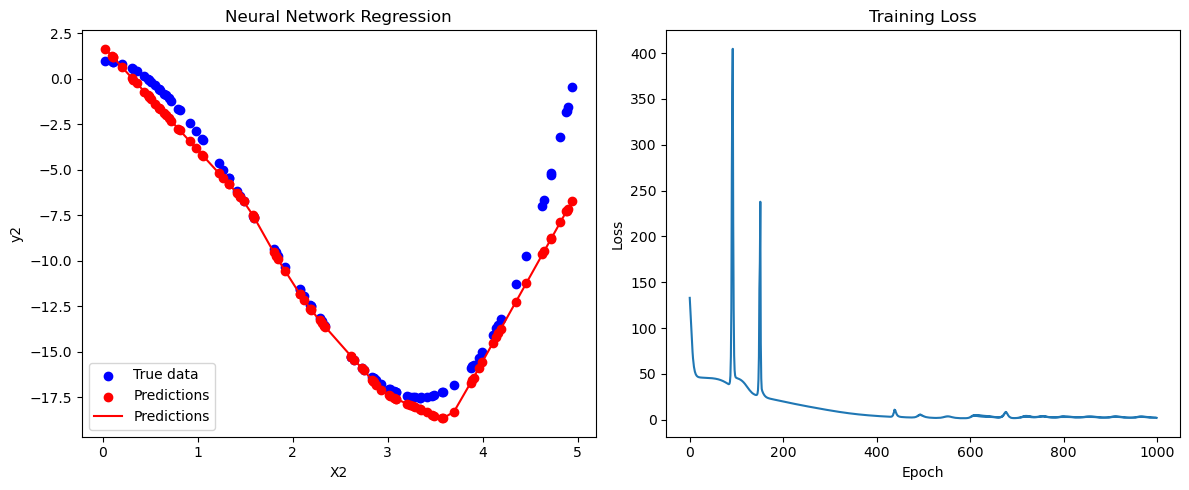

In [44]:
np.random.seed(0)
X2 = np.sort(5 * np.random.rand(100, 1), axis=0)
y2 = X2**3 - 5* X2**2 +1
#y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])
y2 = y2.reshape(-1, 1)

# Initialize neural network
model3 = NeuralNetwork3(input_size=1)
losses3 = []
# training
for epoch in range(epochs):
    y_pred = model3.forward(X2)
    losses3.append(np.mean((y2-y_pred)**2))
    model3.backward(X2, y2, y_pred, learning_rate)
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss:.4f}')
    
# Plot results
plt.figure(figsize=(12, 5))

# Plot training results
plt.subplot(1, 2, 1)
plt.scatter(X2, y2, color='blue', label='True data')
plt.scatter(X2, model3.forward(X2), color='red', label='Predictions')
plt.plot(X2, model3.forward(X2), color='red', label='Predictions')
plt.xlabel('X2')
plt.ylabel('y2')
plt.title('Neural Network Regression')
plt.legend()

# Plot loss curve
plt.subplot(1, 2, 2)
plt.plot(losses3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

plt.tight_layout()
plt.show()